# 音频零基础 2/6：周期、频率、相位与正弦波

这节课从生活中的声音出发，再落到 Python 数组。**先建立直觉，再看公式，最后用代码验证。**

| 项目 | 内容 |
|---|---|
| 本课要回答的问题 | “每秒振动多少次”怎样决定波形的疏密和音高？ |
| 前置要求 | 会运行 Notebook；看不懂代码时先读 Python/PyTorch 基础 1～3 |
| 建议投入 | 90～120 分钟，分成“直觉”和“代码”两次完成也可以 |
| 四个关键词 | 周期、频率、赫兹、相位 |
| 通关证据 | 能用自己的话解释、能算一个数字例子、能画图验证、能从空白实现核心函数 |

本课不是词汇表。每出现一个量，都要写清楚：**它描述什么、单位是什么、数组中怎样表示、改变后听觉或图形怎样变化。**


## 课前回忆：先写猜测，不查答案

1. 对问题““每秒振动多少次”怎样决定波形的疏密和音高？”写下你现在的答案；不会就写“不知道”。
2. 四个关键词中，圈出最陌生的一个：周期 / 频率 / 赫兹 / 相位。
3. 画一条横轴是时间的线，标出 0 秒、0.5 秒和 1 秒。
4. 写下一个可验证的预测：如果把声音的某个参数加倍，图或听感会怎样？

学完后回到这里，用另一种颜色修正。保留错误猜测，它是学习证据。


## 固定观察框架：物理世界 → 数字 → 图 → 听感

```text
声源振动 → 空气压力随时间变化 → 麦克风电信号 → 离散采样值 x[n]
                                                ↓
                                      波形 / 数值统计 / 频谱
```

后面所有 ASR 前端课都沿这条链展开。波形不是声音本身，而是麦克风在一串离散时刻记录下来的数字。


## 1. 频率是每秒完成的周期数

频率单位 Hz（赫兹）等价于“次/秒”。周期是一次完整重复所需的秒数，两者互为倒数。


In [1]:
def period_seconds(frequency_hz: float) -> float:
    if frequency_hz <= 0:
        raise ValueError("frequency_hz must be positive")
    return 1.0 / frequency_hz


for hz in [2, 100, 440, 1000]:
    print(f"{hz:4d} Hz -> period={period_seconds(hz):.6f} s = {period_seconds(hz)*1000:.3f} ms")


   2 Hz -> period=0.500000 s = 500.000 ms
 100 Hz -> period=0.010000 s = 10.000 ms
 440 Hz -> period=0.002273 s = 2.273 ms
1000 Hz -> period=0.001000 s = 1.000 ms


## 2. 同一秒内，频率越高，波形越密

先只比较图的疏密，不急着听。


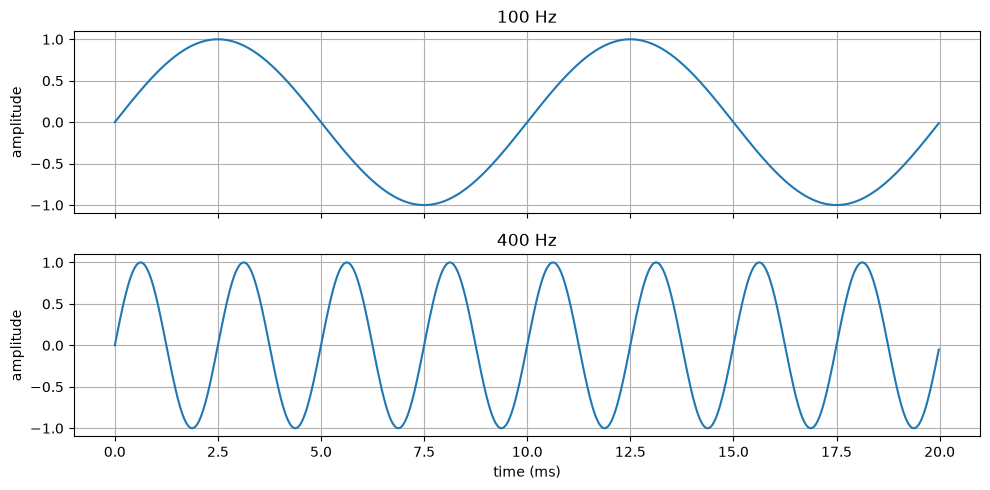

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 0.02, 1000, endpoint=False)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for axis, hz in zip(axes, [100, 400]):
    axis.plot(t * 1000, np.sin(2 * np.pi * hz * t))
    axis.set_title(f"{hz} Hz")
    axis.set_ylabel("amplitude")
    axis.grid(True)
axes[-1].set_xlabel("time (ms)")
plt.tight_layout()
plt.show()


## 3. 相位改变从周期的哪里开始

相位平移波形，但不改变频率。单独听纯音时相位常不明显；叠加和多麦克风处理中却很重要。


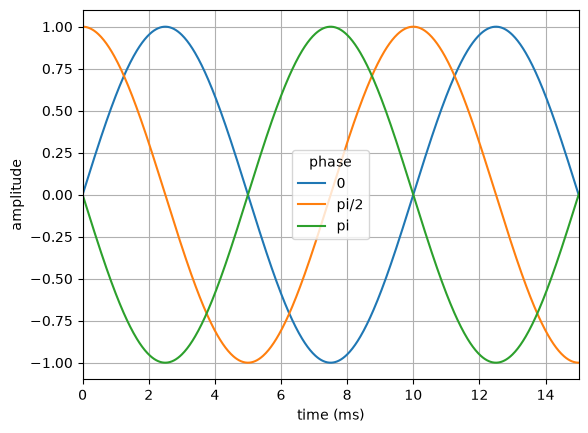

In [3]:
frequency_hz = 100
for phase_name, phase_radians in [("0", 0), ("pi/2", np.pi/2), ("pi", np.pi)]:
    plt.plot(t * 1000, np.sin(2*np.pi*frequency_hz*t + phase_radians), label=phase_name)
plt.xlim(0, 15)
plt.xlabel("time (ms)")
plt.ylabel("amplitude")
plt.legend(title="phase")
plt.grid(True)
plt.show()


## 4. 离散数组中一个周期有多少点

采样率除以频率，得到“每周期样本数”。结果不一定是整数。


In [4]:
def samples_per_period(sample_rate_hz: int, frequency_hz: float) -> float:
    if sample_rate_hz <= 0 or frequency_hz <= 0:
        raise ValueError("rates must be positive")
    return sample_rate_hz / frequency_hz


print("16 kHz recording, 440 Hz tone:", samples_per_period(16_000, 440), "samples/cycle")
print("16 kHz recording, 1 kHz tone:", samples_per_period(16_000, 1_000), "samples/cycle")
assert samples_per_period(16_000, 1_000) == 16


16 kHz recording, 440 Hz tone: 36.36363636363637 samples/cycle
16 kHz recording, 1 kHz tone: 16.0 samples/cycle


## 分层练习：不要一次做完

### A. 直觉与单位（每题 1 分）

1. 不看上文，用一句话定义：周期。
2. 为 `频率` 写出单位；如果它没有单位，要明确说明。
3. 举一个生活中的例子解释 `赫兹`。
4. 画图说明 `相位` 增大时，横轴或纵轴怎样变化。

### B. 数字与预测（每题 2 分）

5. 自己构造一个包含具体数字的计算例子，并标出每一步单位。
6. 把本课一个参数改成 0.5 倍和 2 倍；运行前先画出预期图形。
7. 找出一个“代码能运行，但物理含义错误”的输入，解释为什么错误。
8. 用 `shape / dtype / min / max` 四项审计本课最重要的数组。

### C. 实现与迁移（每题 3 分）

9. 从空白实现：**实现 period_seconds 和 samples_per_period，并验证 frequency×period=1**，不能复制上面的函数。
10. 为实现写正常、边界和错误输入三类测试。
11. 换一组参数或换一条音频，验证结论是否仍成立。
12. 用 90 秒向没学过编程的人解释本课，只允许使用两个术语，并必须包含一个数字例子。

满分 24 分。达到 19 分且第 9～10 题完成，才建议继续；15～18 分次日重做；低于 15 分先回到图和单位。


## 最小掌握门禁

- [ ] 我能把本课每个量说成“含义 + 单位 + 数组表示”。
- [ ] 我能在运行前预测参数变化的方向。
- [ ] 我能从空白完成核心实现并覆盖边界输入。
- [ ] 我能说出一个常见误解，以及用什么证据推翻它。
- [ ] 我已把错题写入根目录 `LEARNING_LOG.md`，并安排明天、7 天、30 天复习。

下一步：音频基础 3：振幅、RMS、功率与 dB。
